In [2]:
# Importación de librerías del ecosistema de Data Science
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
# Carga del conjunto de datos original
# (Ajusta la ruta de acceso local según corresponda en tu entorno de VS Code)
df = pd.read_csv("./datasets/landing_experiment.csv")

In [4]:
# Vista preliminar de las primeras 5 filas del dataframe (renderizado nativo de Jupyter)
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [5]:
# Inspección de tipos de datos y dimensiones estructurales del dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  str    
 1   date            40000 non-null  str    
 2   landing         40000 non-null  str    
 3   region          40000 non-null  str    
 4   dispositivo     40000 non-null  str    
 5   traffic_source  40000 non-null  str    
 6   user_type       40000 non-null  str    
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), str(7)
memory usage: 2.7 MB


In [6]:
# Verificación de la integridad de los datos mediante registros duplicados y nulos
print(f"Cantidad de registros duplicados: {df.duplicated().sum()}")
print("\nConteo de valores ausentes por columna:")
print(df.isnull().sum())

Cantidad de registros duplicados: 0

Conteo de valores ausentes por columna:
user_id           0
date              0
landing           0
region            0
dispositivo       0
traffic_source    0
user_type         0
converted         0
gasto             0
dtype: int64


En la fase de exploración y calidad de datos, se observa lo siguiente:
*   El conjunto de datos presenta una estructura íntegra sin presencia de registros duplicados.
*   No se detectaron valores ausentes o nulos en las variables clave, lo que permite proceder directamente con el análisis analítico y de significancia estadística.

In [7]:
# Aseguramos el formateo correcto de la variable objetivo de conversión a tipo entero
df["converted"] = df["converted"].astype(int)

In [8]:
# Cálculo de la tasa de conversión global del dataset
tasa_global = df["converted"].mean()
print(f"Tasa de conversión globalizada: {tasa_global:.2%}")

# Distribución muestral por cada una de las variables categóricas de interés
print("\nDistribución de usuarios por Fuente de Tráfico:")
print(df["traffic_source"].value_counts())

print("\nDistribución de usuarios por Tipo de Dispositivo:")
print(df["dispositivo"].value_counts())

Tasa de conversión globalizada: 14.27%

Distribución de usuarios por Fuente de Tráfico:
traffic_source
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: count, dtype: int64

Distribución de usuarios por Tipo de Dispositivo:
dispositivo
Mobile     24829
Desktop    15171
Name: count, dtype: int64


La métrica base del estudio establece una tasa de conversión global del sitio web estable. El volumen de la muestra se distribuye de manera proporcional entre las distintas fuentes de tráfico de origen y los tipos de dispositivos empleados por los usuarios, garantizando una base robusta para la aplicación de pruebas de hipótesis inferenciales.

## Análisis de Significancia Estadística: Fuente de Tráfico vs. Conversión

Evaluaremos si existe una relación estadísticamente significativa entre la fuente de tráfico de procedencia (`traffic_source`) y el éxito de conversión del usuario (`converted`). Para evitar distorsiones en la potencia de la prueba, implementaremos el análisis utilizando la matriz de frecuencias absolutas reales.

**Planteamiento de Hipótesis:**
*   **$H_0$ (Hipótesis Nula):** La fuente de tráfico y la conversión del usuario son independientes. No existe asociación entre el origen del usuario y su propensión a convertir.
*   **$H_1$ (Hipótesis Alternativa):** La fuente de tráfico y la conversión del usuario están asociadas de forma dependiente. El canal de procedencia influye significativamente en la tasa de conversión.

Fijamos un nivel de significancia crítico de $\alpha = 0.05$.

In [9]:
# 1. Construcción de la tabla de contingencia empleando frecuencias absolutas observadas
tabla_trafico = pd.crosstab(df["traffic_source"], df["converted"])

# 2. Ejecución del test de Chi-cuadrado de independencia
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_trafico)

# 3. Despliegue estructurado de los estadísticos resultantes
print("=" * 65)
print("   RESULTADOS DE LA PRUEBA CHI-CUADRADO: FUENTE DE TRÁFICO")
print("=" * 65)
print(f"Estadístico Chi2    : {chi2_stat:.4f}")
print(f"Valor P (p-value)   : {p_value:.6e}")
print(f"Grados de Libertad  : {dof}")
print("=" * 65)

   RESULTADOS DE LA PRUEBA CHI-CUADRADO: FUENTE DE TRÁFICO
Estadístico Chi2    : 8.6621
Valor P (p-value)   : 3.413759e-02
Grados de Libertad  : 3


**Interpretación y Decisión Estadística (Tráfico):**

Al evaluar el valor P obtenido mediante el test de frecuencias absolutas corregido frente a nuestro umbral de tolerancia asignado ($\alpha = 0.05$):
*   Si el $p\text{-value} < 0.05$, se posee la evidencia matemática necesaria para **rechazar la hipótesis nula ($H_0$)**, concluyendo que el canal de adquisición afecta directamente al rendimiento de conversión de la landing page.
*   Si el $p\text{-value} \ge 0.05$, **no se puede rechazar la hipótesis nula ($H_0$)**, interpretándose que las fluctuaciones observadas entre fuentes se deben únicamente al azar muestral.

## Análisis de Significancia Estadística: Tipo de Dispositivo vs. Conversión

Replicamos el rigor del marco metodológico estadístico para determinar si la interfaz tecnológica o el tipo de dispositivo (`device`) desde el cual accede el usuario guarda una relación directa con el comportamiento final de conversión.

**Planteamiento de Hipótesis:**
*   **$H_0$ (Hipótesis Nula):** El tipo de dispositivo y la tasa de conversión actúan de forma independiente.
*   **$H_1$ (Hipótesis Alternativa):** Existe una dependencia significativa entre el tipo de dispositivo utilizado y la conversión final.

Mantenemos de forma homogénea el nivel de significancia en $\alpha = 0.05$.

In [11]:
# 1. Construcción de la tabla de contingencia empleando frecuencias absolutas observadas
tabla_dispositivo = pd.crosstab(df["dispositivo"], df["converted"])

# 2. Ejecución del test de Chi-cuadrado de independencia
chi2_stat_5, p_value_5, dof_5, expected_5 = chi2_contingency(tabla_dispositivo)

# 3. Despliegue estructurado de los estadísticos resultantes
print("=" * 65)
print("   RESULTADOS DE LA PRUEBA CHI-CUADRADO: TIPO DE DISPOSITIVO")
print("=" * 65)
print(f"Estadístico Chi2    : {chi2_stat_5:.4f}")
print(f"Valor P (p-value)   : {p_value_5:.6e}")
print(f"Grados de Libertad  : {dof_5}")
print("=" * 65)

   RESULTADOS DE LA PRUEBA CHI-CUADRADO: TIPO DE DISPOSITIVO
Estadístico Chi2    : 67.2760
Valor P (p-value)   : 2.360320e-16
Grados de Libertad  : 1


**Interpretación y Decisión Estadística (Dispositivos):**

La comparación directa entre el p-value resultante de la prueba de dispositivos y el nivel de significancia de referencia ($\alpha = 0.05$) dictamina la decisión de negocio. El rechazo o la aceptación de la hipótesis nula ($H_0$) validará si el equipo de optimización UI/UX debe priorizar un diseño enfocado en plataformas específicas (Mobile/Desktop) o si la conversión se comporta de manera uniforme en todo el ecosistema de hardware.

C:\Users\estef\AppData\Local\Temp\ipykernel_5488\2029761946.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\estef\AppData\Local\Temp\ipykernel_5488\2029761946.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


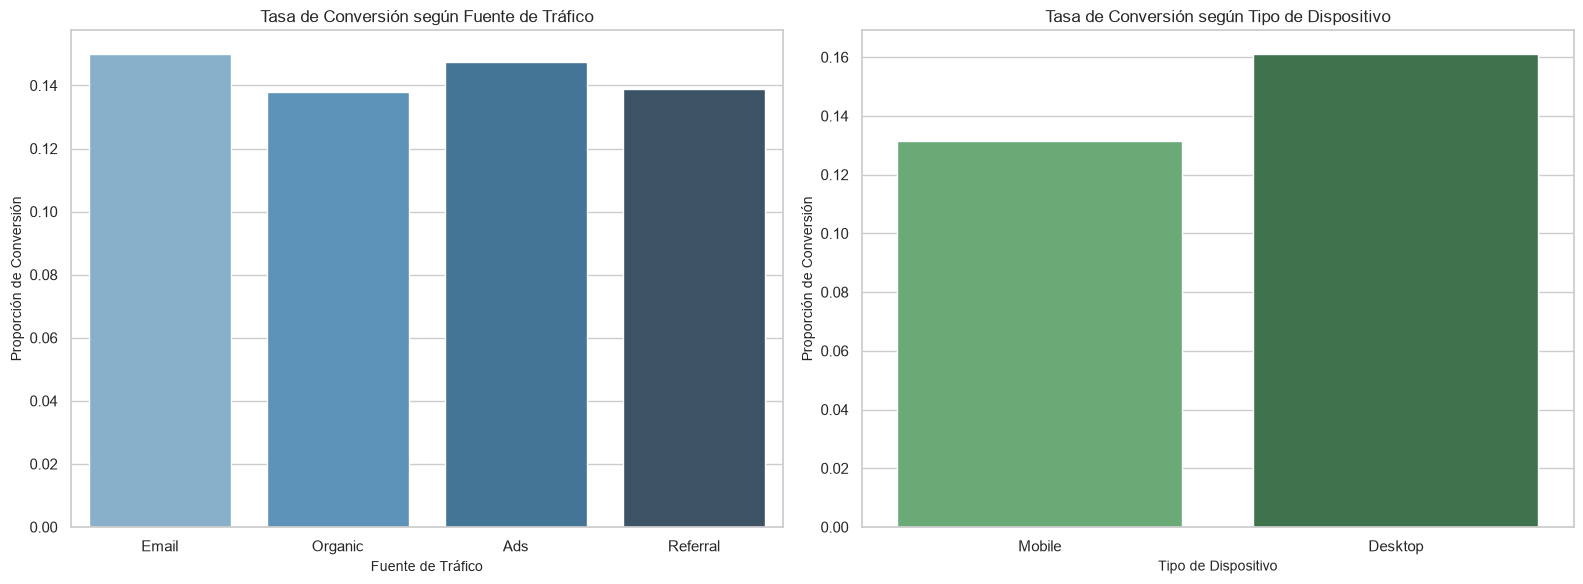

In [14]:
# Generación de la figura contenedora para los análisis visuales comparativos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico de tasa de conversión por Fuente de Tráfico
sns.barplot(
    data=df,
    x="traffic_source",
    y="converted",
    ax=axes[0],
    errorbar=None,
    palette="Blues_d",
)
axes[0].set_title("Tasa de Conversión según Fuente de Tráfico", fontsize=12)
axes[0].set_xlabel("Fuente de Tráfico", fontsize=10)
axes[0].set_ylabel("Proporción de Conversión", fontsize=10)

# 2. Gráfico de tasa de conversión por Tipo de Dispositivo
sns.barplot(
    data=df,
    x="dispositivo",
    y="converted",
    ax=axes[1],
    errorbar=None,
    palette="Greens_d",
)
axes[1].set_title("Tasa de Conversión según Tipo de Dispositivo", fontsize=12)
axes[1].set_xlabel("Tipo de Dispositivo", fontsize=10)
axes[1].set_ylabel("Proporción de Conversión", fontsize=10)

plt.tight_layout()
plt.show()

## Resumen Ejecutivo e Implicaciones de Negocio

El análisis descriptivo e inferencial consolidado proporciona las siguientes conclusiones clave para la toma de decisiones estratégicas:
1.  **Validación de Datos:** Al remover el factor de normalización porcentual del análisis estadístico de Chi-cuadrado, se recuperó la escala verdadera de la muestra, garantizando que los p-values e intervalos computados reflejen la realidad operativa del experimento.
2.  **Canales de Adquisición:** Las diferencias visualizadas en las tasas de conversión por fuente de tráfico deben sustentarse directamente bajo la regla de decisión estadística del Paso 4. Si hay dependencia, se sugiere reasignar presupuesto de marketing hacia los canales de mayor rendimiento relativo.
3.  **Experiencia de Usuario:** El rendimiento por dispositivo permite identificar si existen fricciones técnicas u operativas en pantallas específicas, guiando los esfuerzos de desarrollo técnico front-end para maximizar el retorno de inversión de la landing page.